# Phase 2: 家計への帰着 — 所得階層別インフレ負担

コストプッシュインフレが所得階層別にどう帰着するかを分析する。

**実効インフレ負担**: effective_inflation(q,t) = Σ_cat [share(q,cat) × ΔCPI(cat,t)]

低所得層（Q1）は食料・光熱費の支出シェアが高く、これらは輸入含有率が高い → 逆進性

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import japanize_matplotlib

from src.analysis.quintile_impact import (
    compute_quintile_inflation_burden,
    compute_quintile_real_income_change,
    load_expenditure_shares,
)
from src.analysis.bridge_matrix import (
    compute_hh_category_import_content,
    classify_necessity_discretionary,
    HH_CATEGORY_MAP,
)

## 2-1. 費目別輸入含有率と必需品/裁量品の分類

Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/bridge-matrix/necessity_classification.csv


/var/folders/dq/w27rxm_96b522vs0dsrq53fw0000gn/T/ipykernel_95253/3605814284.py:20: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/var/folders/dq/w27rxm_96b522vs0dsrq53fw0000gn/T/ipykernel_95253/3605814284.py:21: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic.
  plt.savefig('../data/processed/bridge-matrix/fig_import_content_necessity.png', dpi=150, bbox_inches='tight')
/Users/ishidatomonori/Desktop/graduation-thesis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


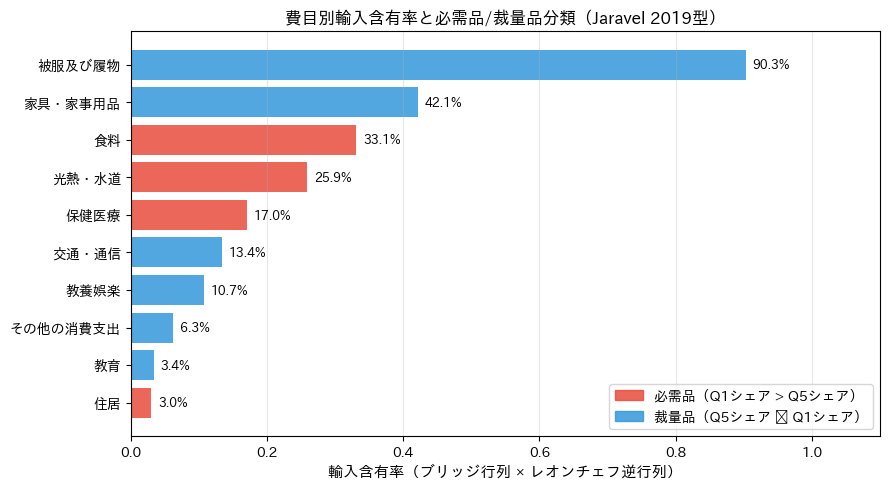

hh_cat_name  share_q1  share_q5  is_necessity  import_content
         住居    0.0569    0.0432          True          0.0302
         教育    0.0058    0.0625         False          0.0341
   その他の消費支出    0.1530    0.2043         False          0.0626
       教養娯楽    0.0686    0.1057         False          0.1071
      交通・通信    0.1016    0.1508         False          0.1336
       保健医療    0.0511    0.0384          True          0.1703
      光熱・水道    0.0847    0.0542          True          0.2588
         食料    0.2546    0.2123          True          0.3311
    家具・家事用品    0.0342    0.0347         False          0.4212
     被服及び履物    0.0215    0.0437         False          0.9031


In [2]:
nd_df = classify_necessity_discretionary()
nd_df = nd_df.sort_values('import_content', ascending=True)

colors = ['#e74c3c' if n else '#3498db' for n in nd_df['is_necessity']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(nd_df['hh_cat_name'], nd_df['import_content'], color=colors, alpha=0.85)
ax.set_xlabel('輸入含有率（ブリッジ行列 × レオンチェフ逆行列）', fontsize=11)
ax.set_title('費目別輸入含有率と必需品/裁量品分類（Jaravel 2019型）', fontsize=12)

for bar, val in zip(bars, nd_df['import_content']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

necessity_patch = mpatches.Patch(color='#e74c3c', alpha=0.85, label='必需品（Q1シェア > Q5シェア）')
discretionary_patch = mpatches.Patch(color='#3498db', alpha=0.85, label='裁量品（Q5シェア ≥ Q1シェア）')
ax.legend(handles=[necessity_patch, discretionary_patch], loc='lower right')
ax.set_xlim(0, 1.1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/bridge-matrix/fig_import_content_necessity.png', dpi=150, bbox_inches='tight')
plt.show()
print(nd_df[['hh_cat_name', 'share_q1', 'share_q5', 'is_necessity', 'import_content']].to_string(index=False))

## 2-2. 所得五分位別の実効インフレ負担

Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/price-indices/cpi_changes.csv
Saved quintile inflation burden to /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/simulation-params/quintile_inflation_burden.csv (66 rows)


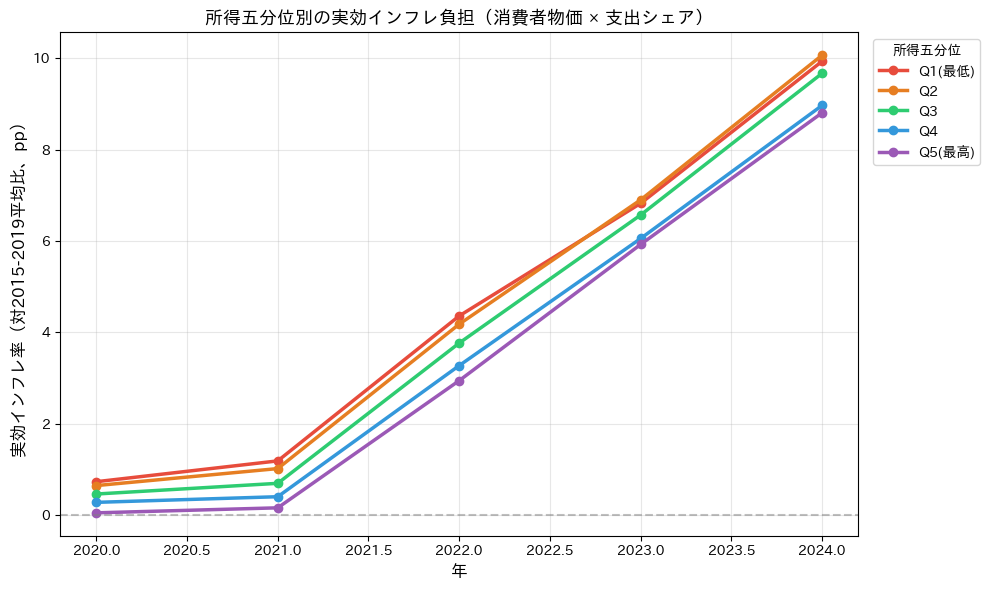

quintile_label  Q1(最低)     Q2    Q3    Q4  Q5(最高)    平均
year                                                   
2020              0.73   0.64  0.46  0.27    0.04  0.37
2021              1.18   1.01  0.69  0.40    0.15  0.60
2022              4.36   4.18  3.76  3.27    2.94  3.58
2023              6.82   6.90  6.57  6.05    5.92  6.37
2024              9.94  10.07  9.67  8.97    8.81  9.38


In [3]:
burden = compute_quintile_inflation_burden()
# Focus on 2020-2024
plot_burden = burden[burden['year'].between(2020, 2024)]
pivot = plot_burden.pivot(index='year', columns='quintile_label', values='effective_inflation_pp')

fig, ax = plt.subplots(figsize=(10, 6))
line_styles = ['-', '--', ':', '-.', '-', '--']
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

for (col, color) in zip(['Q1(最低)', 'Q2', 'Q3', 'Q4', 'Q5(最高)'], colors):
    if col in pivot.columns:
        ax.plot(pivot.index, pivot[col], marker='o', label=col, color=color, linewidth=2.5)

ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('実効インフレ率（対2015-2019平均比、pp）', fontsize=12)
ax.set_title('所得五分位別の実効インフレ負担（消費者物価 × 支出シェア）', fontsize=13)
ax.legend(title='所得五分位', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/processed/simulation-params/fig_quintile_inflation_burden.png', dpi=150, bbox_inches='tight')
plt.show()
print(pivot.round(2))

## 2-3. 逆進性: Q1−Q5 格差の推移

Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/simulation-params/quintile_inflation_burden.csv
Saved quintile real income comparison to /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/simulation-params/quintile_real_income.csv


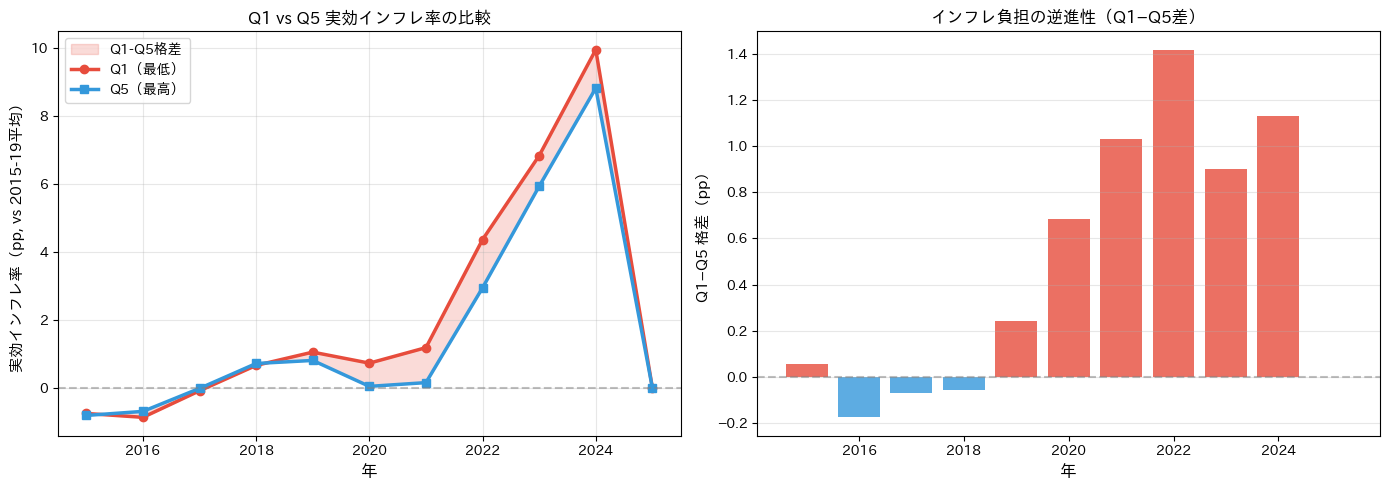


=== Q1-Q5 逆進性格差 ===
 year  Q1(最低)  Q5(最高)  Q1_minus_Q5_gap
 2015   -0.75   -0.81             0.06
 2016   -0.87   -0.69            -0.18
 2017   -0.09   -0.02            -0.07
 2018    0.66    0.72            -0.06
 2019    1.05    0.80             0.24
 2020    0.73    0.04             0.68
 2021    1.18    0.15             1.03
 2022    4.36    2.94             1.42
 2023    6.82    5.92             0.90
 2024    9.94    8.81             1.13
 2025    0.00    0.00             0.00


In [4]:
gap_df = compute_quintile_real_income_change()
gap_plot = gap_df[gap_df['year'].between(2015, 2025)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Q1 vs Q5 over time
ax = axes[0]
ax.fill_between(gap_plot['year'], gap_plot['Q1(最低)'], gap_plot['Q5(最高)'],
                alpha=0.2, color='#e74c3c', label='Q1-Q5格差')
ax.plot(gap_plot['year'], gap_plot['Q1(最低)'], 'o-', color='#e74c3c', label='Q1（最低）', linewidth=2.5)
ax.plot(gap_plot['year'], gap_plot['Q5(最高)'], 's-', color='#3498db', label='Q5（最高）', linewidth=2.5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('実効インフレ率（pp, vs 2015-19平均）', fontsize=11)
ax.set_title('Q1 vs Q5 実効インフレ率の比較', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Right: gap Q1-Q5
ax = axes[1]
gap_vals = gap_plot['Q1_minus_Q5_gap']
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in gap_vals]
ax.bar(gap_plot['year'], gap_vals, color=colors_bar, alpha=0.8)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('Q1−Q5 格差（pp）', fontsize=11)
ax.set_title('インフレ負担の逆進性（Q1−Q5差）', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/simulation-params/fig_q1_q5_regressivity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Q1-Q5 逆進性格差 ===')
print(gap_df[['year', 'Q1(最低)', 'Q5(最高)', 'Q1_minus_Q5_gap']].round(2).to_string(index=False))

## 2-4. 支出構成の違い — なぜ逆進的なのか

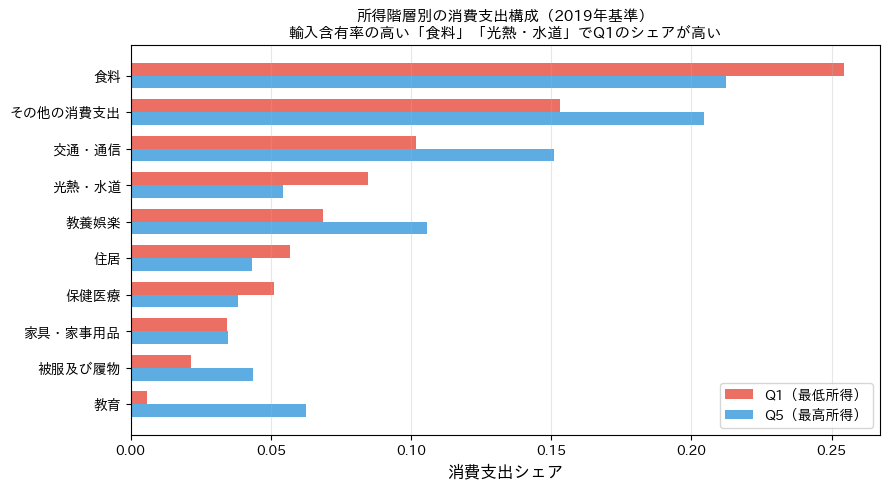

In [5]:
shares = load_expenditure_shares(2019)
cat_names = {code: cat['name'] for code, cat in HH_CATEGORY_MAP.items()}
shares_named = shares.rename(columns=cat_names)

# Q1 vs Q5 comparison
compare = pd.DataFrame({
    'Q1（最低）': shares_named.loc[1],
    'Q5（最高）': shares_named.loc[5],
}).sort_values('Q1（最低）', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(compare))
width = 0.35
ax.barh([i + width/2 for i in x], compare['Q1（最低）'], width, label='Q1（最低所得）', color='#e74c3c', alpha=0.8)
ax.barh([i - width/2 for i in x], compare['Q5（最高）'], width, label='Q5（最高所得）', color='#3498db', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(compare.index)
ax.set_xlabel('消費支出シェア', fontsize=12)
ax.set_title('所得階層別の消費支出構成（2019年基準）\n輸入含有率の高い「食料」「光熱・水道」でQ1のシェアが高い', fontsize=11)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/simulation-params/fig_expenditure_shares_q1_q5.png', dpi=150, bbox_inches='tight')
plt.show()